In [118]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [119]:
import logging
import os

import matplotlib.pyplot as plt  # type: ignore
import numpy as np
from pixell import curvedsky

import lenspyx
import healpy as hp

from scripts import Core
from scripts.utils import (
    remove_mono_dipole,
    setup_logging,
    plot_cl_alm,
    plot_patches,
    plot_predictions,
)

from notebooks.ksw_joblib import KSW_joblib

In [120]:
logger = setup_logging(__name__, level=logging.DEBUG)

## Setup

In [121]:
core = Core(
    [
        # "settings/l256_n64.json",
        "settings/l2000_n2048.json",
        "--nsims",
        "5",
        "--narray",
        "1",
        "--fnl_range",
       "-50", "50",
        # "--no-noise",
        "--lensing",
        "--pols",
    ]
)

08-Jul-24 16:39:02 - scripts.core - DEBUG - Parsing CLI args: ['settings/l2000_n2048.json', '--nsims', '5', '--narray', '1', '--fnl_range', '-50', '50', '--lensing', '--pols']
08-Jul-24 16:39:02 - scripts.core - INFO - Loading settings from file settings/l2000_n2048.json
08-Jul-24 16:39:02 - scripts.core - DEBUG - Forcing setting 'nsims' to '5' due to CLI
08-Jul-24 16:39:02 - scripts.core - DEBUG - Forcing setting 'narray' to '1' due to CLI
08-Jul-24 16:39:02 - scripts.core - DEBUG - Forcing setting 'fnl_range' to '[-50.0, 50.0]' due to CLI
08-Jul-24 16:39:02 - scripts.core - DEBUG - Forcing setting 'lensing' to 'True' due to CLI
08-Jul-24 16:39:02 - scripts.core - DEBUG - Forcing setting 'pols' to 'True' due to CLI
08-Jul-24 16:39:02 - scripts.core - DEBUG - Found non-default value for 'cosmo_params': {'H0': 67.4, 'As': 2.457e-09, 'ns': 0.9649, 'ombh2': 0.0224, 'omch2': 0.12, 'tau': 0.054, 'max_l': 2500, 'lmax': 2000} (default: {'As': 2.13e-09, 'ns': 0.9624, 'pivot_scalar': 0.05, 'lma

08-Jul-24 16:39:02 - scripts.core - DEBUG - Using polarizations: ('T', 'E')
08-Jul-24 16:39:02 - scripts.core - DEBUG - Setting 'double_precision' not found, using default: False
08-Jul-24 16:39:02 - scripts.core - DEBUG - Using single precision, where possible
08-Jul-24 16:39:02 - scripts.core - DEBUG - Setting 'num-estimates' not found, using default: 10
08-Jul-24 16:39:02 - scripts.core - DEBUG - Setting 'noise' not found, using default: True
08-Jul-24 16:39:02 - scripts.core - DEBUG - Setting 'noise_scale_ee' not found, using default: 1
08-Jul-24 16:39:02 - scripts.core - DEBUG - Setting 'noise_scale_bb' not found, using default: 0
08-Jul-24 16:39:02 - scripts.core - DEBUG - Setting 'noise_scale_te' not found, using default: 1
08-Jul-24 16:39:02 - scripts.core - DEBUG - Setting 'r_min' not found, using default: 1
08-Jul-24 16:39:02 - scripts.core - DEBUG - Setting 'r_max' not found, using default: 50000
08-Jul-24 16:39:02 - scripts.core - INFO - SLURM job id: 13631455
08-Jul-24 16:

## Alm

This code generates the alms

$$a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}^{NG}$$
with
$$a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]$$
and
$$\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)$$
$$\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)$$
$$B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}$$
where $\Delta_\phi$ is primordial normalization, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions   

In [122]:
from scripts.generator import generate_alm, generate_alm_ng

In [123]:
alm_l = generate_alm(core)
alm_ng = generate_alm_ng(core, alm_l)

fnls = core.rng.uniform(core.fnl_min, core.fnl_max, core.fnl_shape)

alms = alm_l + fnls[:, None, :] * alm_ng
alms = remove_mono_dipole(alms)
print(alms.shape)

08-Jul-24 16:40:15 - scripts.generator - DEBUG - Using temp folder for Alm_ng generation: /lustre/scratch/client/users/stevensonb


Alm_ng:   0%|          | 0/10 [00:00<?, ?it/s]

(5, 2, 2003001)


alm2lenmap: using 128 nthreads
  build angles <- synthesis (GRAD_ONLY):  [0:00:00.561692] (40.6%)  
  build angles <- th-phi-gm (ducc)     :  [0:00:00.051013] (3.7%)  
  build_angles                         :  [0:00:00.612738] (44.3%)  
  synthesis general (STANDARD)         :  [0:00:00.344749] (24.9%)  
  gclm2lenmap                          :  [0:00:01.365271] (98.8%)  
  synthesis general (GRAD_ONLY)        :  [0:00:00.378088] (27.3%)  
  polrot (ducc)                        :  [0:00:00.029603] (2.1%)  
  Total                                :  [0:00:01.382453] d:h:m:s:mus


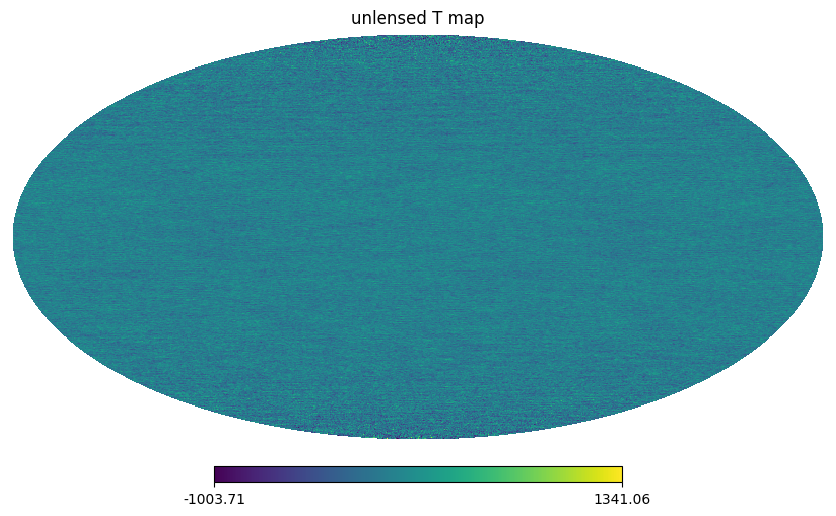

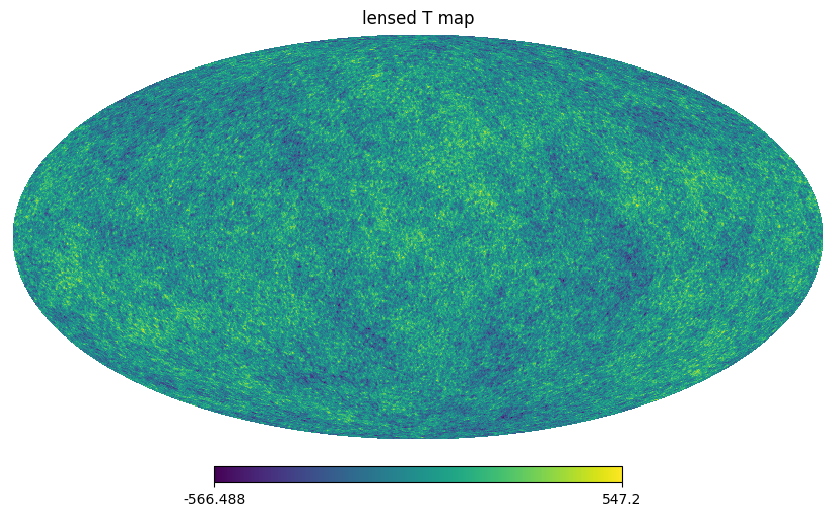

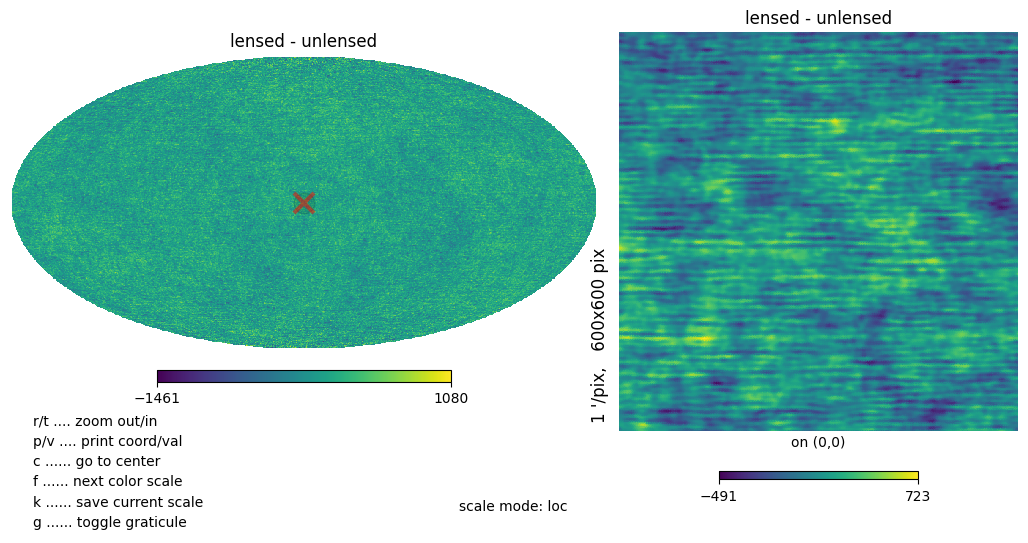

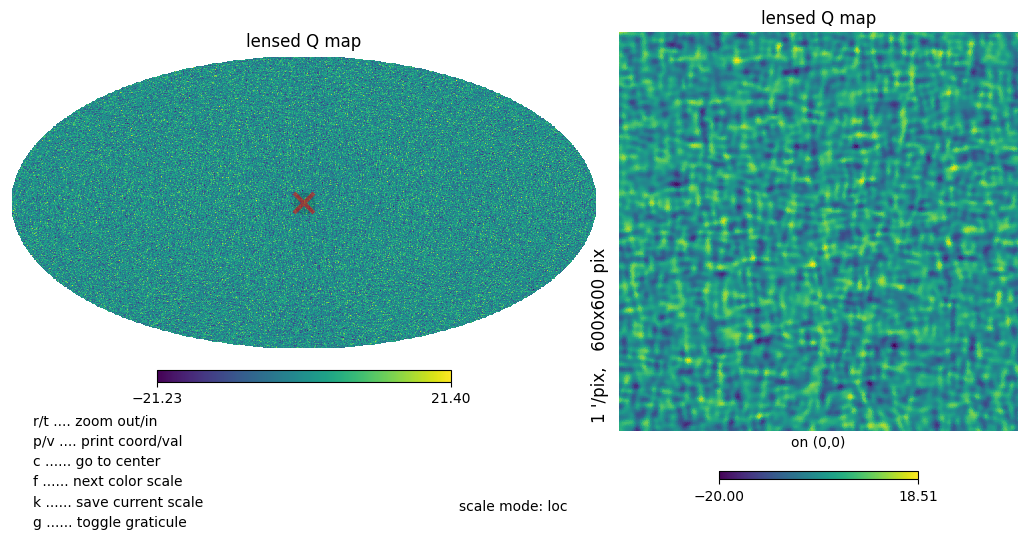

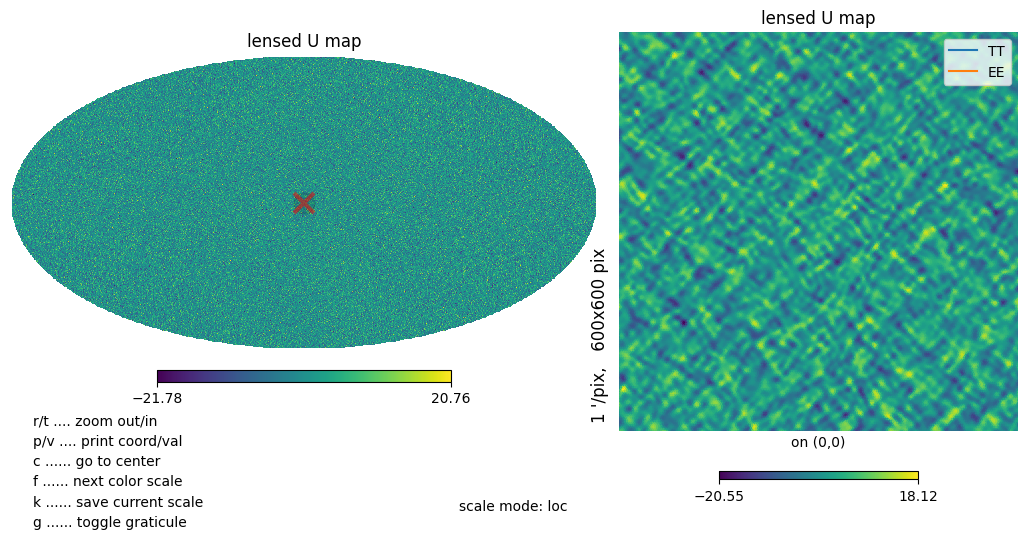

In [124]:
if core.lensing:
    cl_phi = core.cosmo._camb_data.get_lens_potential_cls(  # type: ignore
        core.max_l, CMB_unit="muK", raw_cl=True
    )

    plm = lenspyx.utils_hp.synalm(cl_phi[:, 0], lmax=core.max_l, mmax=None)

    # transform the lensing potential into spin-1 deflection field
    fl = np.sqrt(np.arange(core.max_l + 1) * np.arange(1, core.max_l + 2))
    dlm = lenspyx.utils_hp.almxfl(plm, fl, mmax=None, inplace=False)

    geom_info = ("healpix", {"nside": core.nside})
    geom = lenspyx.get_geom(geom_info)

    Tunl = geom.alm2map(alms[0, 0], core.max_l, core.max_l, nthreads=os.cpu_count())
    Tlen, Qlen, Ulen = lenspyx.alm2lenmap(alms[0], dlm, geometry=geom_info, verbose=1)

    hp.mollview(Tunl, title="unlensed T map")
    hp.mollview(Tlen, title="lensed T map")
    hp.mollzoom(Tlen - Tunl, title="lensed - unlensed")
    hp.mollzoom(Qlen, title="lensed Q map")
    hp.mollzoom(Ulen, title="lensed U map")

    T = geom.map2alm(Tlen, core.lmax, core.lmax, nthreads=os.cpu_count())
    E, B = geom.map2alm_spin(
        [Qlen, Ulen], 2, core.lmax, core.lmax, nthreads=os.cpu_count()
    )
    tlm_len = geom.map2alm(Tlen, core.lmax, core.lmax, nthreads=os.cpu_count())

    cltt_len = lenspyx.utils_hp.alm2cl(T, T, core.lmax, core.lmax, core.lmax)
    clee_len = lenspyx.utils_hp.alm2cl(E, E, core.lmax, core.lmax, core.lmax)
    clbb_len = lenspyx.utils_hp.alm2cl(B, B, core.lmax, core.lmax, core.lmax)
    ls = np.arange(2, core.lmax - 32)

    cltt_unl = core.c_ells[0]
    clee_unl = core.c_ells[1]
    clbb_unl = core.c_ells[2]

    plt.plot(ls, cltt_len[ls] / cltt_unl[ls], label="TT")
    # plt.plot(ls, cltt_len[ls] / cltt_unl[ls], c="k")

    plt.plot(ls, clee_len[ls] / clee_unl[ls], label="EE")
    # plt.plot(ls, clee_len[ls] / clee_unl[ls], c="k", ls="--")
    # plt.ylim(0.8, 1.4)
    plt.legend()

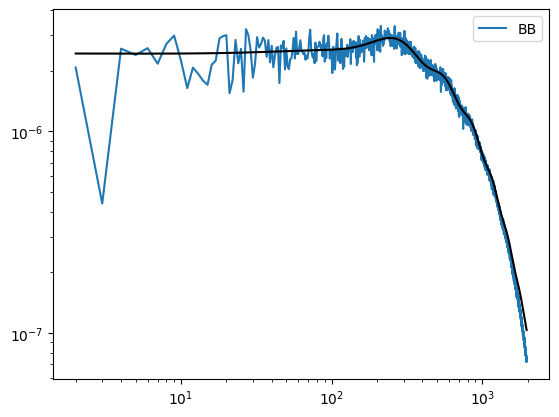

In [125]:
if core.lensing:
    plt.loglog(ls, clbb_len[ls], label="BB")
    plt.plot(ls, clbb_unl[ls], c="k")
    plt.legend()

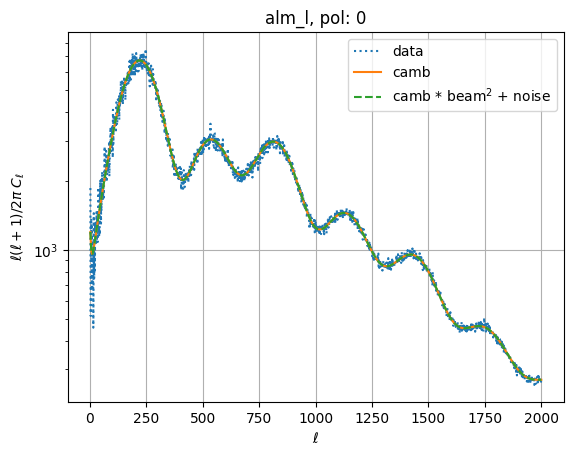

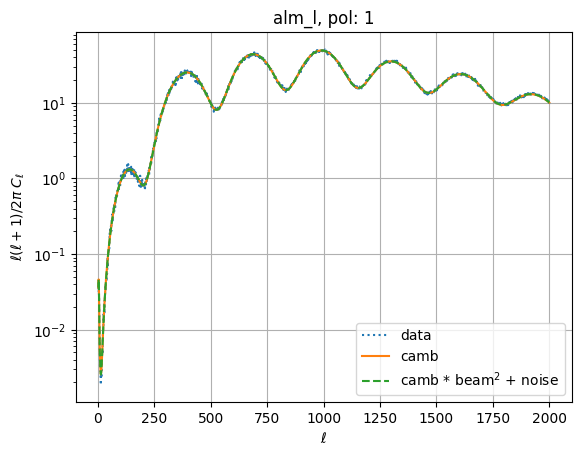

In [126]:
for pol in range(core.npol):
    plot_cl_alm(
        alm_l[0, pol],
        title=f"alm_l, pol: {pol}",
        plot_camb=True,
        c_ells=core.c_ells[pol],
        camb_noise=True,
        noise=core.noise_ell[pol],
        beam_width=core.beam_width,
    )

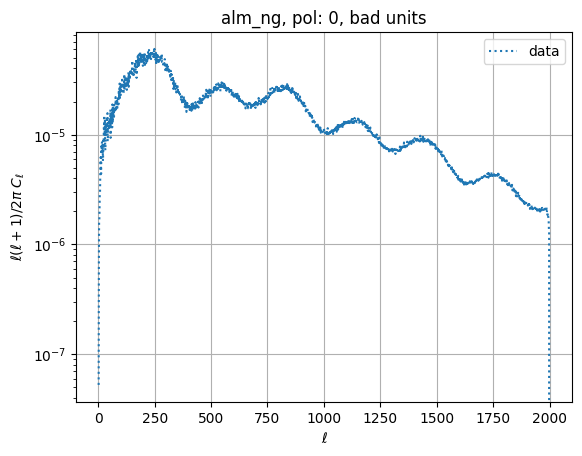

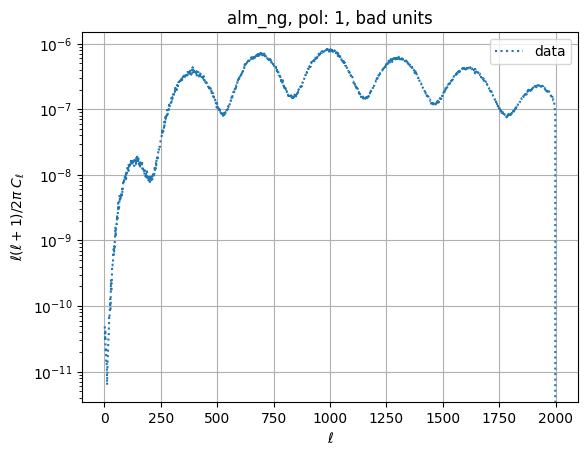

In [127]:
for pol in range(core.npol):
    plot_cl_alm(alm_ng[0, pol], title=f"alm_ng, pol: {pol}, bad units")

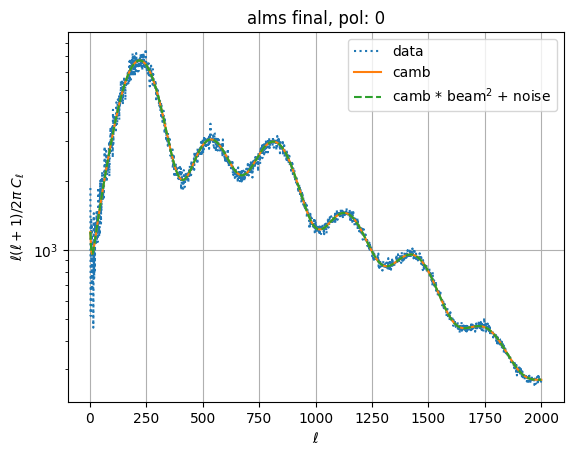

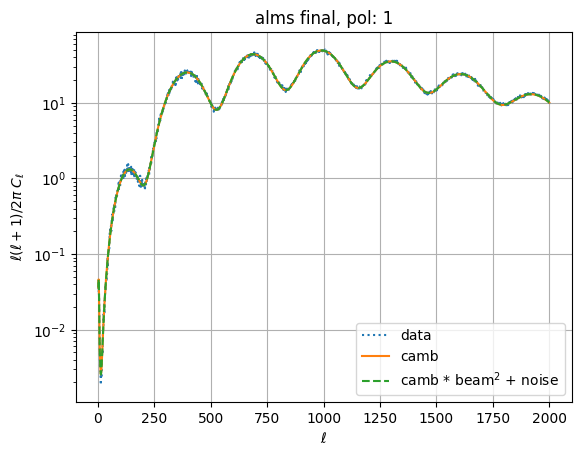

In [128]:
for pol in range(core.npol):
    plot_cl_alm(
        alms[0, pol],
        title=f"alms final, pol: {pol}",
        plot_camb=True,
        c_ells=core.c_ells[pol],
        camb_noise=True,
        noise=core.noise_ell[pol],
        beam_width=core.beam_width,
    )

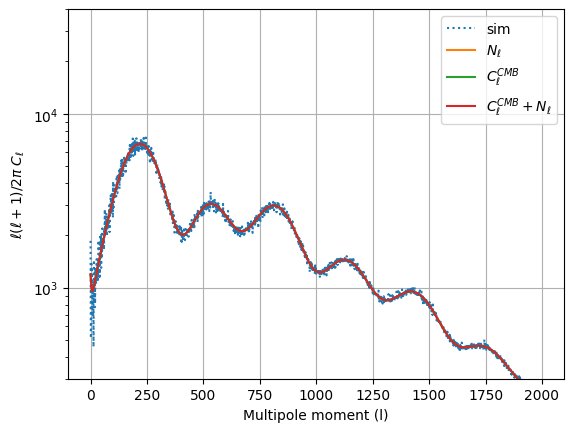

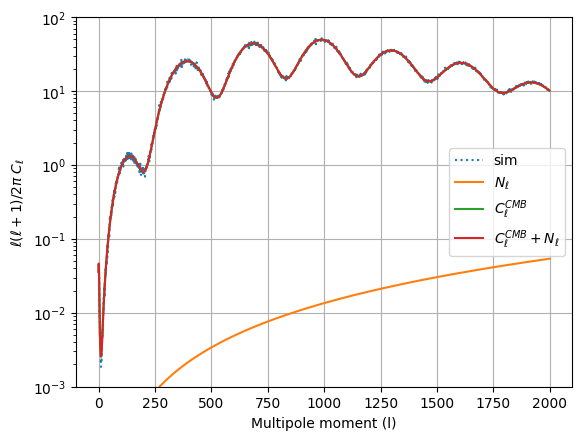

In [129]:
for pol in range(core.npol):
    ells = np.arange(2, core.nell)
    scale = ells * (ells + 1) / 2 / np.pi
    N_ell = core.noise_ell[pol, 2:]
    cl_cmb = core.c_ells[pol, 2 : core.nell]
    cl_sim = curvedsky.alm2cl(alms[0, pol])[2 : core.nell]
    beam = core.beam_ell[pol, 2:]

    plot_func = plt.semilogy
    plot_func(scale * cl_sim, label=r"sim", linestyle=":")
    plot_func(scale * N_ell, label=r"$N_\ell$")
    plot_func(scale * cl_cmb, label=r"$C_{\ell}^{CMB}$")
    plot_func(scale * (cl_cmb * beam**2 + N_ell), label=r"$C_\ell^{CMB} + N_\ell$")

    plt.legend()
    plt.xlabel("Multipole moment (l)")
    plt.ylabel(r"$\ell(\ell+1)/2\pi\;C_{\ell}$")
    plt.grid(True)
    if pol == 0:
        plt.ylim([3e2, 4e4])
    if pol == 1:
        plt.ylim([1e-3, 1e2])
    plt.show()

In [130]:
from pixell import curvedsky, enmap, reproject

In [131]:
cl_phi = core.cosmo._camb_data.get_lens_potential_cls(  # type: ignore
    core.lmax, CMB_unit="muK", raw_cl=True
)
plm = lenspyx.utils_hp.synalm(cl_phi[:, 0], lmax=core.lmax, mmax=None)

# transform the lensing potential into spin-1 deflection field
fl = np.sqrt(np.arange(core.nell) * np.arange(1, core.nell + 1))
dlm = lenspyx.utils_hp.almxfl(plm, fl, mmax=None, inplace=False)

geom_info = ("healpix", {"nside": core.nside})
geom = lenspyx.get_geom(geom_info)

ps_rad = np.deg2rad(core.patch_side_deg)
res = ps_rad / core.nside

fs_shape, fs_wcs = enmap.fullsky_geometry(res, proj="car")
fs_shape = (core.npol,) + fs_shape
fs_map = enmap.empty(fs_shape, fs_wcs)

patch_shapes = []
patch_wcss = []
for counter in range(core.npatches // 2):
    # [[dec_min,ra_min],[dec_max,ra_max]]
    top = [[0, ps_rad * counter], [ps_rad, ps_rad * (counter + 1)]]
    gs, w = enmap.geometry(pos=top, res=res, proj="car")
    patch_shapes.append(gs)
    patch_wcss.append(w)

    bottom = [[-ps_rad, ps_rad * counter], [0, ps_rad * (counter + 1)]]
    gs, w = enmap.geometry(pos=bottom, res=res, proj="car")
    patch_shapes.append(gs)
    patch_wcss.append(w)

In [132]:
# convert the map into a pixell map to allow for projection
if core.lensing:
    patches = np.empty(
        (core.nsims, core.npatches, 3, core.nside, core.nside), dtype=core.r_dtype
    )
    alm_lensed = np.empty((core.nsims, 3, core.nelem), dtype=core.c_dtype)
    for sim in range(core.nsims):
        lens_map = lenspyx.alm2lenmap(alms[sim], dlm, geometry=geom_info, verbose=0)
        pixell_map = reproject.healpix2map(lens_map, fs_shape, fs_wcs, core.lmax)
        # logger.info("pixell_map shape: %s", pixell_map.shape)

        # cut the patches
        for i in range(core.npatches):
            ret = pixell_map.project(patch_shapes[i], patch_wcss[i])
            patches[sim, i] = pixell_map.project(patch_shapes[i], patch_wcss[i])

        alm_lensed[sim, 0] = geom.map2alm(
            lens_map[0], core.lmax, core.lmax, nthreads=os.cpu_count()
        )
        alm_lensed[sim, 1:] = geom.map2alm_spin(
            lens_map[1:], 2, core.lmax, core.lmax, nthreads=os.cpu_count()
        )

    print(patches.shape)

: 

In [ ]:
if not core.lensing:
    # unlensed
    fs_map = enmap.empty(fs_shape, fs_wcs)
    patches = np.empty(
        (core.nsims, core.npatches, core.npol, core.nside, core.nside),
        dtype=core.r_dtype,
    )
    for sim in range(core.nsims):
        car_map = curvedsky.alm2map(alms[sim], fs_map, spin=[0, 0])

        for i in range(core.npatches):
            patch = car_map.project(patch_shapes[i], patch_wcss[i])  # type: ignore
            patches[sim, i] = patch

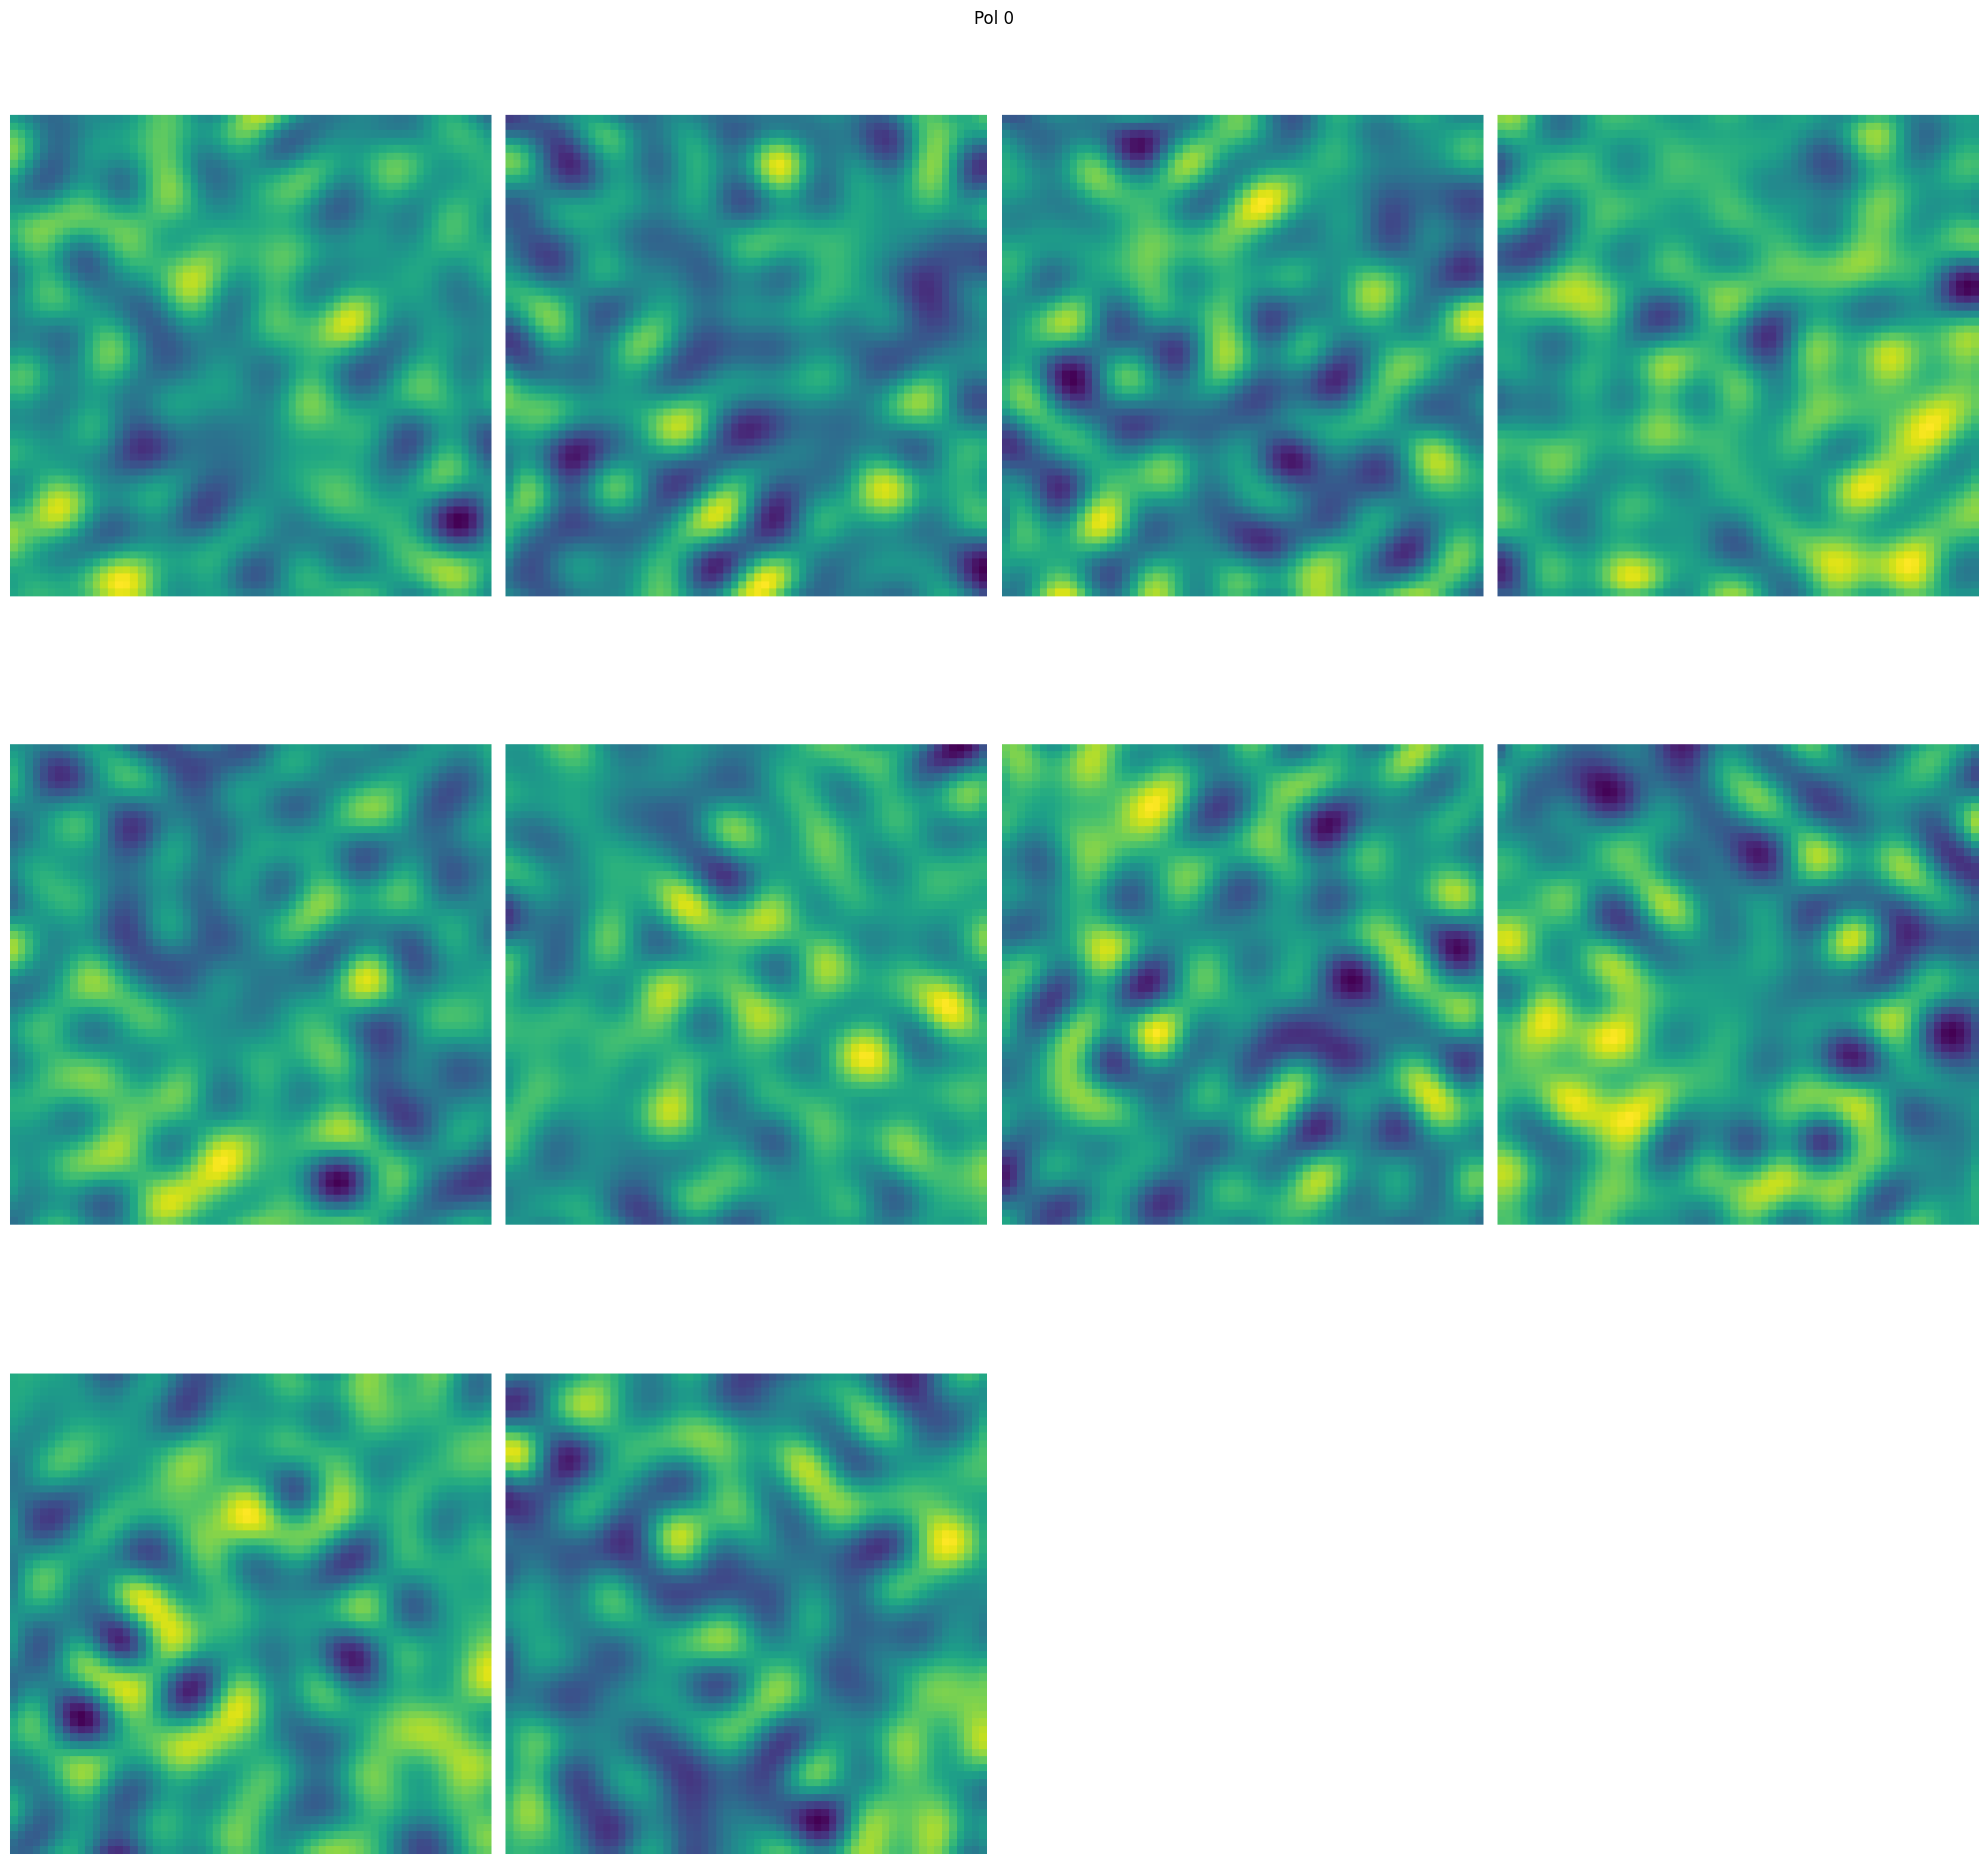

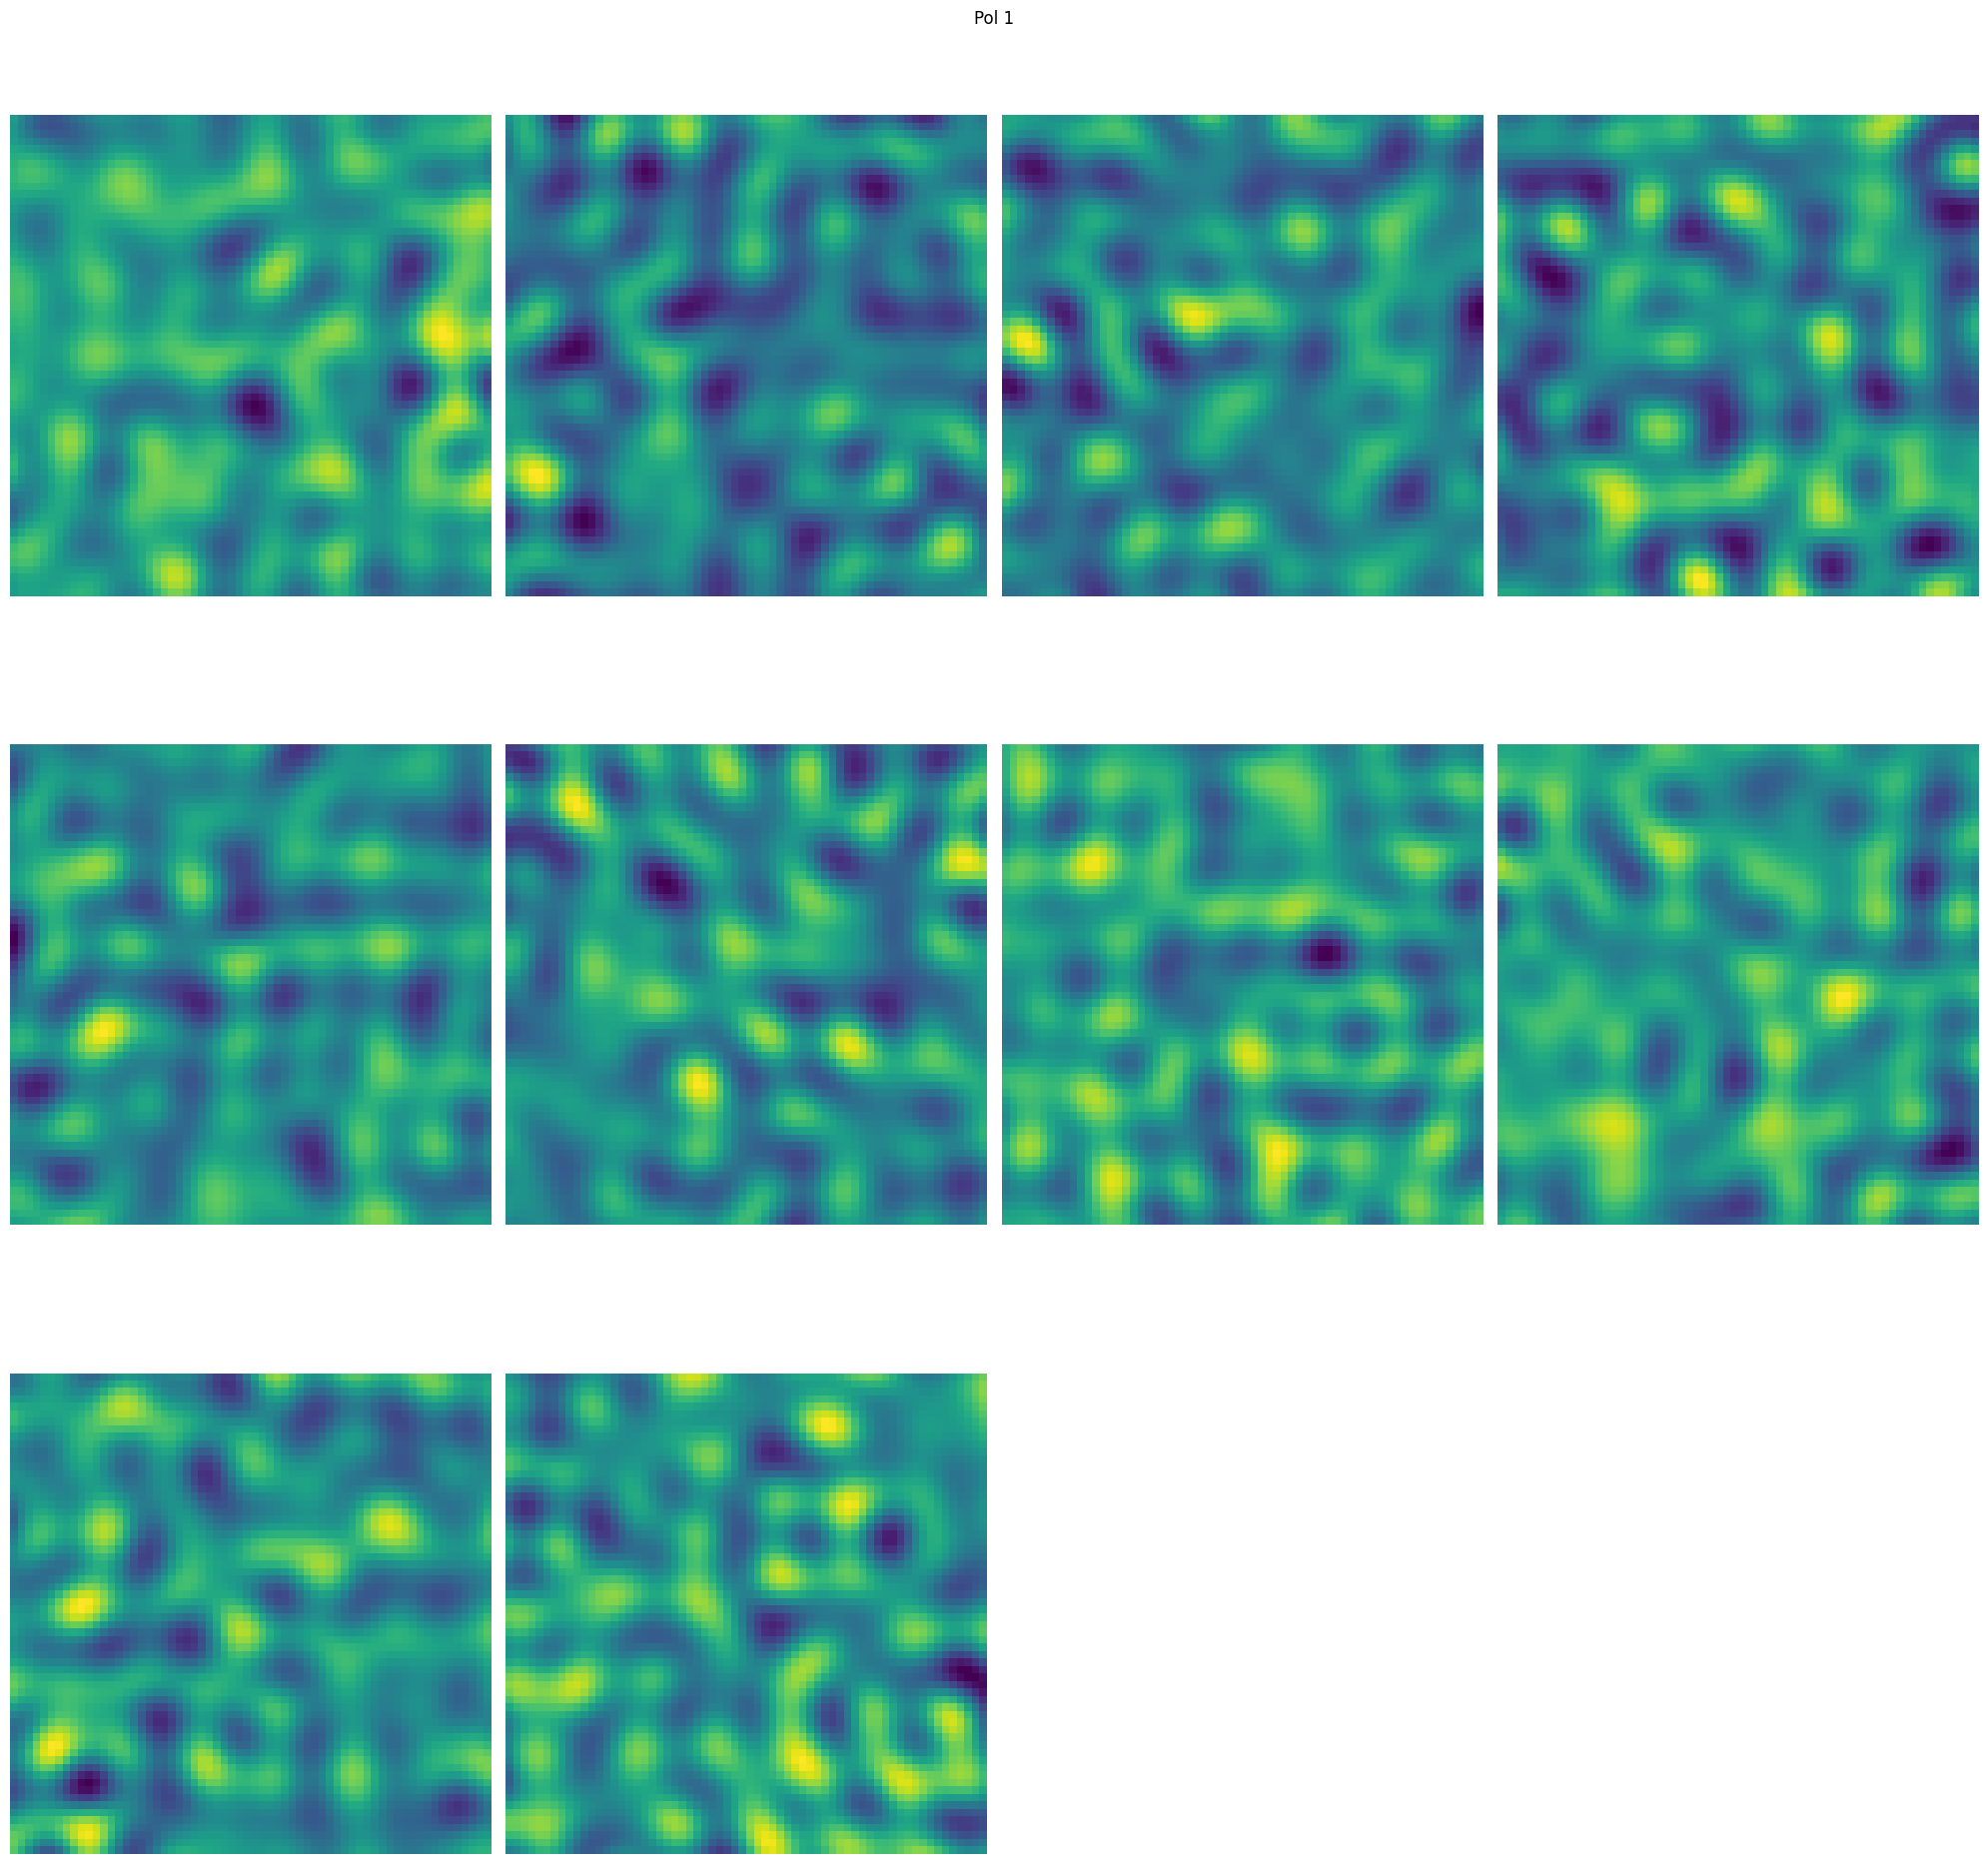

In [ ]:
for pol in range(core.npol):
    plot_patches(patches[0, :, pol], 10, title=f"Pol {pol}")

## Estimator

In [ ]:
from ksw import Cosmology, Shape
import camb
from scripts.estimator import icov_func, conv_beam_func

In [ ]:
mc_path = os.path.join(core.base_dir, "kswmc")
os.makedirs(mc_path, exist_ok=True)
mc_file = os.path.join(mc_path, f"{core.base_name}.hdf5")

cosmo_params = core.cosmo_params
cosmo = Cosmology(camb.set_params(**cosmo_params))
cosmo.compute_transfer(core.max_l)
cosmo.compute_c_ell()

pols = tuple([pol for pol in core.pols if pol != "B"])  # remove the b-modes
npols = len(pols)
nnoise = 1 if npols == 1 else 3

noise = core.noise_ell[:nnoise]
beam = core.beam_ell[:npols]

loc_shape = Shape.prim_local(cosmo_params["ns"], cosmo_params["pivot_scalar"])
cosmo.add_prim_reduced_bispectrum(loc_shape, core.radii)

icov = icov_func(beam, noise[:npols], core.c_ells[:npols])

ksw = KSW_joblib(
    cosmo.red_bispectra,
    icov,
    conv_beam_func(core, npols),
    core.lmax,
    pols,
    core.precision,
)

# uncomment to remove the mc file to regenerated
if os.path.exists(mc_file):
    os.remove(mc_file)

theta_batch = int(np.floor(1.5 * core.lmax + 1)) // len(os.sched_getaffinity(0))

if os.path.exists(mc_file):
    logger.info("Loading KSW state from %s", mc_file)
    ksw.start_from_read_state(mc_file, None)
else:

    step_alms = generate_alm(core, 100)

    def alm_step_loader(idx):
        return step_alms[idx, :npols]

    ksw.step_batch(alm_step_loader, range(100), theta_batch=theta_batch)

    logger.info("Saving KSW state to %s", mc_file)
    ksw.write_state(mc_file)

08-Jul-24 16:23:41 - notebooks.ksw_joblib - INFO - Using KSW_joblib
08-Jul-24 16:23:42 - notebooks.ksw_joblib - INFO - processing 0
08-Jul-24 16:23:43 - notebooks.ksw_joblib - INFO - processing 1
08-Jul-24 16:23:44 - notebooks.ksw_joblib - INFO - processing 2
08-Jul-24 16:23:45 - notebooks.ksw_joblib - INFO - processing 3
08-Jul-24 16:23:45 - notebooks.ksw_joblib - INFO - processing 4
08-Jul-24 16:23:46 - notebooks.ksw_joblib - INFO - processing 5
08-Jul-24 16:23:47 - notebooks.ksw_joblib - INFO - processing 6
08-Jul-24 16:23:47 - notebooks.ksw_joblib - INFO - processing 7
08-Jul-24 16:23:48 - notebooks.ksw_joblib - INFO - processing 8
08-Jul-24 16:23:49 - notebooks.ksw_joblib - INFO - processing 9
08-Jul-24 16:23:50 - notebooks.ksw_joblib - INFO - processing 10
08-Jul-24 16:23:51 - notebooks.ksw_joblib - INFO - processing 11
08-Jul-24 16:23:51 - notebooks.ksw_joblib - INFO - processing 12
08-Jul-24 16:23:52 - notebooks.ksw_joblib - INFO - processing 13
08-Jul-24 16:23:53 - notebooks.k

In [ ]:
fisher = ksw.compute_fisher()
logger.info("Fisher: %s, standard deviation: %s", fisher, np.sqrt(1 / fisher))

08-Jul-24 16:25:03 - __main__ - INFO - Fisher: 0.004799139614466792, standard deviation: 14.435050507368393


In [ ]:
def alm_loader(i):
    return alms[i, : core.npol]


idxs = range(alms.shape[0])

estimates = ksw.compute_estimate_batch(
    alm_loader, idxs, theta_batch=theta_batch, fisher=fisher
)

08-Jul-24 16:25:33 - notebooks.ksw_joblib - DEBUG - t_cubic: -0.09729890525341034, lin_term: 0.015045022606941924, fisher: 0.004799139614466792
08-Jul-24 16:25:33 - notebooks.ksw_joblib - INFO - estimate: -23.40918099604698
08-Jul-24 16:25:33 - notebooks.ksw_joblib - DEBUG - t_cubic: 0.08595416520984145, lin_term: 0.023712802844322742, fisher: 0.004799139614466792
08-Jul-24 16:25:33 - notebooks.ksw_joblib - INFO - estimate: 12.969275196307043
08-Jul-24 16:25:34 - notebooks.ksw_joblib - DEBUG - t_cubic: -0.19714477110210282, lin_term: 0.013073127181496584, fisher: 0.004799139614466792
08-Jul-24 16:25:34 - notebooks.ksw_joblib - INFO - estimate: -43.80324707576895
08-Jul-24 16:25:34 - notebooks.ksw_joblib - DEBUG - t_cubic: -0.14563487490522675, lin_term: 0.0043172956749372845, fisher: 0.004799139614466792
08-Jul-24 16:25:34 - notebooks.ksw_joblib - INFO - estimate: -31.245636223655573
08-Jul-24 16:25:35 - notebooks.ksw_joblib - DEBUG - t_cubic: 0.08342732810706366, lin_term: -0.01413362

08-Jul-24 16:27:16 - __main__ - INFO - Standard deviation: 14.435050507368393
08-Jul-24 16:27:16 - __main__ - INFO - 48.0% are within 1 standard deviations
08-Jul-24 16:27:16 - __main__ - INFO - 84.0% are within 2 standard deviations
08-Jul-24 16:27:16 - __main__ - INFO - 97.0% are within 3 standard deviations
08-Jul-24 16:27:16 - scripts.utils.plots - DEBUG - (100, 2) (100, 1) (100,)


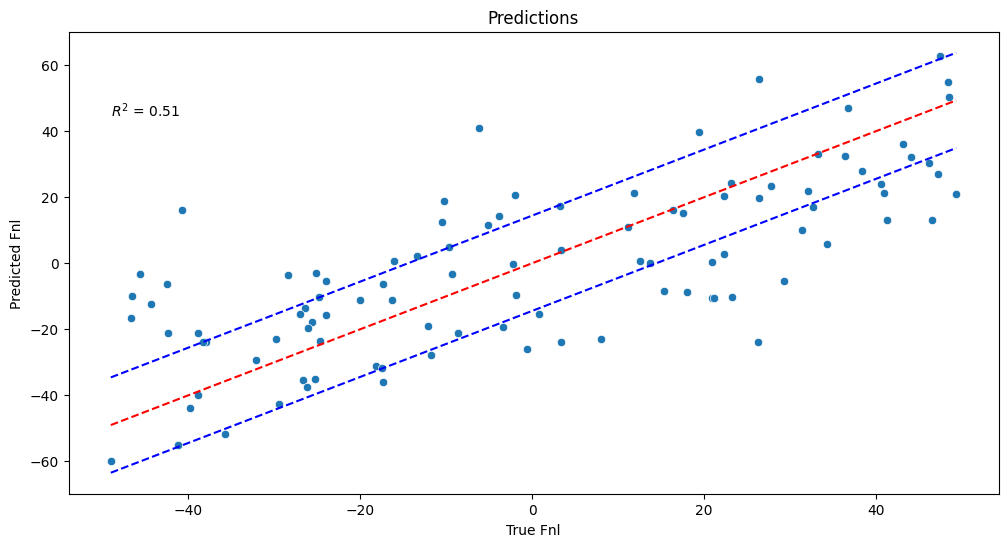

In [ ]:
diff = estimates - fnls[:, 0]
std_dev = np.sqrt(1 / fisher)
logger.info("Standard deviation: %s", std_dev)
for i in range(3):
    within = np.sum(np.abs(diff) < ((i + 1) * std_dev))
    percentage = within / len(diff) * 100
    logger.info("%s%% are within %s standard deviations", percentage, i + 1)

plot_predictions(fnls, estimates, fisher=fisher)